<a href="https://colab.research.google.com/github/T-Svitlichna/DTA_Python/blob/main/Proekt_1/notekooks/melbourne_houses_analyse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Melbourne Housing Snapshot

  Dataset was scraped from publicly available results posted every week from Domain.com.au
  This is intended as a static (unchanging) snapshot of https://www.kaggle.com/anthonypino/melbourne-housing-market. It was created in September 2017. Additionally, homes with no Price have been removed.

#Overview
  File informations
- melb_data.csv(2.09 MB)
- number of Rows 13580
- namber of Columns 21


#

| Column name | Description | Example Value |
|---|---|---|
| Suburb | Suburb name | Abbotsford |
| Address | Street address | 85 Turner St |
| Rooms | Number of rooms | 2 |
| Type | h = house/cottage/villa/semi/terrace · u = unit/duplex · t = townhouse · dev site = development site · o res = other residential | h, u, t |
| Price | Price in dollars | 1480000 |
| Method | See note below | S, SP, PI |
| SellerG | Real Estate Agent | Biggin |
| Date | Date sold | 3/12/2016 |
| Distance | Distance from CBD | 2.5 |
| Postcode | Postcode | 3067 |
| Bedroom2 | Scraped # of Bedrooms (from different source) | 2 |
| Bathroom | Number of Bathrooms | 1 |
| Car | Number of carspots | 1 |
| Landsize | Land Size in m² | 202 |
| BuildingArea | Building Size in m² | 126 |
| YearBuilt | Year built | 1970 |
| CouncilArea | Governing council for the area | Yarra City Council |
| Lattitude | Latitude coordinate | -37.7996 |
| Longtitude | Longitude coordinate | 144.9984 |
| Regionname | General Region (West, North West, North, North East etc.) | Northern Metropolitan |
| Propertycount | Number of properties that exist in the suburb | 4019 |

---

**Method values:**
- **S** — property sold
- **SP** — sold prior
- **PI** — passed in
- **PN** — sold prior not disclosed
- **SN** — sold not disclosed
- **NB** — no bid
- **VB** — vendor bid
- **W** — withdrawn prior to auction
- **SA** — sold after auction
- **SS** — sold after auction, price not disclosed
- **N/A** — price or highest bid not available

!pip install numpy pandas matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt

FILE_IN = 'https://raw.githubusercontent.com/T-Svitlichna/Melbourne_housing/refs/heads/main/data/melb_data.csv'
FILE_OUT = "data/Melbourne_houses_analyse.csv"

df_origin = pd.read_csv(FILE_IN)



#Primary diagnosis

In [2]:
df_origin.head()
df = df_origin.copy()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


Problem:

Date columns (Transaction Date) as object

Find  dirty  and Null values

In [3]:
print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing/len(df) * 100).round(2)
missing_rep = pd.DataFrame({
    "count": missing,
    "%": missing_pct
})
print(missing_rep)
missnotnull = missing_rep[missing_rep["%"] > 0]

Missing values:

               count      %
Suburb             0   0.00
Address            0   0.00
Rooms              0   0.00
Type               0   0.00
Price              0   0.00
Method             0   0.00
SellerG            0   0.00
Date               0   0.00
Distance           0   0.00
Postcode           0   0.00
Bedroom2           0   0.00
Bathroom           0   0.00
Car               62   0.46
Landsize           0   0.00
BuildingArea    6450  47.50
YearBuilt       5375  39.58
CouncilArea     1369  10.08
Lattitude          0   0.00
Longtitude         0   0.00
Regionname         0   0.00
Propertycount      0   0.00


,count,%
Car,62,0.46
BuildingArea,6450,47.50
YearBuilt,5375,39.58
CouncilArea,1369,10.08


In [16]:
dirty = ["ERROR", "UNKNOWN", "UNK", "N/A", "?", "-", ""," " "NONE", "NULL"]

for col in ['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount']:
    count = df[col].astype(str).str.upper().isin(dirty).sum()
    nan = df[col].isna().sum()
    display(f"{col}: брудних={count}, NaN={nan}")

'Suburb: брудних=0, NaN=0'

'Address: брудних=0, NaN=0'

'Rooms: брудних=0, NaN=0'

'Type: брудних=0, NaN=0'

'Price: брудних=0, NaN=0'

...

'CouncilArea: брудних=0, NaN=1369'

'Lattitude: брудних=0, NaN=0'

'Longtitude: брудних=0, NaN=0'

'Regionname: брудних=0, NaN=0'

'Propertycount: брудних=0, NaN=0'

Dirty value didn't find

# BUILDING AREA: MISSING VALUE ANALYSIS & IMPUTATION STRATEGY

In [27]:
(df["BuildingArea"] == 0).sum()

np.int64(17)

STEP 1: Replace 0 with NaN
# 0 is not a valid building area — treat as missing

In [28]:
df['BuildingArea'] = df['BuildingArea'].replace(0, np.nan)

print(f"Missing values: {df['BuildingArea'].isna().sum()} ({df['BuildingArea'].isna().mean()*100:.1f}%)")

Missing values: 6467 (47.6%)


# STEP 2: Split into complete and missing subsets
# We analyse only complete data to avoid biased conclusions

In [29]:
df_complete = df[df['BuildingArea'].notna()].copy()
df_missing  = df[df['BuildingArea'].isna()].copy()

print(f"Complete rows : {len(df_complete)}")
print(f"Missing rows  : {len(df_missing)}")

Complete rows : 7113
Missing rows  : 6467


In [47]:
df_complete.BuildingArea.describe()

,BuildingArea
count,7113.000000
mean,152.330851
std,541.609671
min,1.000000
25%,93.000000
50%,126.000000
75%,174.000000
max,44515.000000


STEP 3: Correlation with numeric features
# Higher value = stronger relationship with BuildingArea

In [30]:
corr = df_complete[['BuildingArea', 'Rooms', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'Price']]\
    .corr()['BuildingArea'].sort_values(ascending=False)

print("\nCorrelation with BuildingArea:")
print(corr)


Correlation with BuildingArea:
BuildingArea    1.000000
Landsize        0.500594
Rooms           0.124682
Bedroom2        0.122895
Bathroom        0.112263
Car             0.096332
Price           0.091576
Name: BuildingArea, dtype: float64


# STEP 4: Visual check — which features best explain area?
# Box plots show how BuildingArea varies across categories

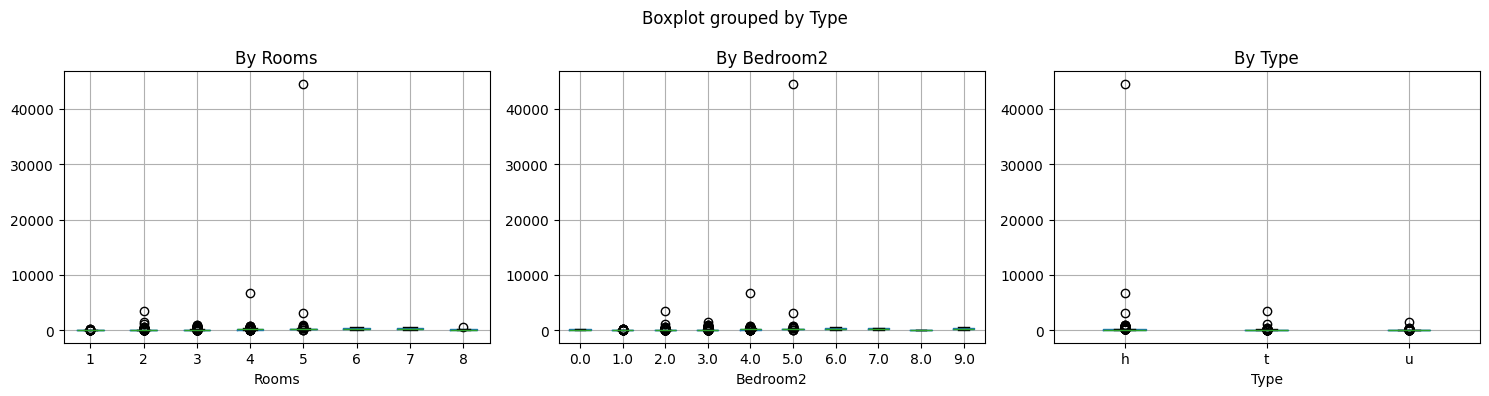

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('BuildingArea distribution by key features', fontsize=13)

df_complete.boxplot(column='BuildingArea', by='Rooms',  ax=axes[0])
axes[0].set_title('By Rooms')

df_complete.boxplot(column='BuildingArea', by='Bedroom2', ax=axes[1])
axes[1].set_title('By Bedroom2')

df_complete.boxplot(column='BuildingArea', by='Type', ax=axes[2])
axes[2].set_title('By Type')

plt.tight_layout()
plt.show()

# STEP 5: Group consistency check
# Lower std = more uniform group = more accurate median imputation

In [32]:
for col in ['Type', 'Regionname', 'Rooms']:
    stats = df_complete.groupby(col)['BuildingArea'].agg(['median', 'std', 'count'])
    print(f"\n--- {col} ---")
    print(stats)



--- Type ---
      median         std  count
Type                           
h      144.0  651.425837   4846
t      130.0  147.949634    683
u       75.0   50.631211   1584

--- Regionname ---
                            median          std  count
Regionname                                            
Eastern Metropolitan        149.50   263.566018    708
Eastern Victoria            156.50   108.954623     30
Northern Metropolitan       111.00   101.721008   2090
Northern Victoria           150.00  8382.051281     28
South-Eastern Metropolitan  146.00    81.709115    220
Southern Metropolitan       130.00   119.692902   2409
Western Metropolitan        130.00    73.861282   1607
Western Victoria            122.86    58.144875     21

--- Rooms ---
       median          std  count
Rooms                            
1        50.0    23.023727    348
2        85.0    98.749108   1866
3       130.0    62.669643   2958
4       190.0   184.975558   1550
5       260.0  2388.996557    345
6  

In [35]:
combos = {
    'Rooms'                  : df_complete.groupby('Rooms')['BuildingArea'].std().mean(),
    'Type'                   : df_complete.groupby('Type')['BuildingArea'].std().mean(),
    'Regionname'             : df_complete.groupby('Regionname')['BuildingArea'].std().mean(),
    'Rooms + Type'           : df_complete.groupby(['Rooms','Type'])['BuildingArea'].std().mean(),
    'Rooms + Regionname'     : df_complete.groupby(['Rooms','Regionname'])['BuildingArea'].std().mean(),
    'Type + Regionname'      : df_complete.groupby(['Type','Regionname'])['BuildingArea'].std().mean(),
    'Rooms + Type + Regionname': df_complete.groupby(['Rooms','Type','Regionname'])['BuildingArea'].std().mean(),
}

result = pd.Series(combos).sort_values()
print("\nFeature combinations ranked by group consistency (lower = better):")
print(result)


Feature combinations ranked by group consistency (lower = better):
Rooms + Type                  223.939881
Type                          283.335561
Rooms                         406.416281
Rooms + Type + Regionname     429.644575
Type + Regionname             551.612740
Rooms + Regionname            741.889951
Regionname                   1148.712638
dtype: float64


In [36]:
df_complete[df_complete['Regionname'] == 'Northern Victoria']['BuildingArea'].describe()

,BuildingArea
count,28.000000
mean,1746.374286
std,8382.051281
min,61.000000
25%,130.730000
50%,150.000000
75%,194.250000
max,44515.000000


In [39]:
from scipy import stats
features = ['Type', 'Rooms', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'Price' ]

for col in features:
    groups = [group['BuildingArea'].dropna().values
              for _, group in df_complete.groupby(col)]

    stat, p = stats.kruskal(*groups)

    significance = "✅ significant" if p < 0.05 else "❌ not significant"
    print(f"{col:20} | H={stat:.1f} | p={p:.4f} | {significance}")

Type                 | H=2386.1 | p=0.0000 | ✅ significant
Rooms                | H=4362.8 | p=0.0000 | ✅ significant
Bedroom2             | H=4234.4 | p=0.0000 | ✅ significant
Bathroom             | H=3059.1 | p=0.0000 | ✅ significant
Car                  | H=1793.9 | p=0.0000 | ✅ significant
Landsize             | H=3302.7 | p=0.0000 | ✅ significant
Price                | H=3910.5 | p=0.0000 | ✅ significant


In [40]:
for col in ['Type', 'Regionname', 'Rooms']:
    grouped = df_complete.groupby(col)['BuildingArea'].median()
    spread = grouped.max() - grouped.min()
    cv = df_complete.groupby(col)['BuildingArea'].std().mean() / \
         df_complete['BuildingArea'].median() * 100
    print(f"{col:20} | розкид медіан: {spread:.0f}м² | CV: {cv:.1f}%")

Type                 | розкид медіан: 69м² | CV: 224.9%
Regionname           | розкид медіан: 46м² | CV: 911.7%
Rooms                | розкид медіан: 286м² | CV: 322.6%


In [41]:
combos = {
    'Rooms + Type': df_complete.groupby(['Rooms','Type']),
    'Rooms + Regionname': df_complete.groupby(['Rooms','Regionname']),
    'Type + Regionname': df_complete.groupby(['Type','Regionname']),
    'Rooms + Type + Regionname': df_complete.groupby(['Rooms','Type','Regionname']),
}

for name, grouped in combos.items():
    cv = grouped['BuildingArea'].std().mean() / \
         df_complete['BuildingArea'].median() * 100
    spread = grouped['BuildingArea'].median().max() - \
             grouped['BuildingArea'].median().min()
    print(f"{name:30} | розкид: {spread:.0f}м² | CV: {cv:.1f}%")

Rooms + Type                   | розкид: 286м² | CV: 177.7%
Rooms + Regionname             | розкид: 569м² | CV: 588.8%
Type + Regionname              | розкид: 99м² | CV: 437.8%
Rooms + Type + Regionname      | розкид: 576м² | CV: 341.0%


In [43]:
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error
# Тестуємо на повних даних — ховаємо 20% і перевіряємо точність
test = df_complete[['BuildingArea','Rooms','Bathroom','Car','Price']].copy()

# Штучно створюємо пропуски для тесту
np.random.seed(42)
mask = np.random.rand(len(test)) < 0.2
true_values = test.loc[mask, 'BuildingArea'].copy()
test.loc[mask, 'BuildingArea'] = np.nan

results = {}
for k in [3, 5, 10, 15, 20]:
    imputer = KNNImputer(n_neighbors=k)
    imputed = imputer.fit_transform(test)
    predicted = imputed[mask, 0]
    mae = mean_absolute_error(true_values, predicted)
    results[k] = mae
    print(f"k={k:3} | MAE = {mae:.1f}м²")

best_k = min(results, key=results.get)
print(f"\nНайкращий k = {best_k}")

k=  3 | MAE = 72.4м²
k=  5 | MAE = 71.4м²
k= 10 | MAE = 72.6м²
k= 15 | MAE = 72.7м²
k= 20 | MAE = 74.2м²

Найкращий k = 5


Test size     : 7113 rows
Hidden values : 1463 rows (20.6%)

k=  3  |  MAE = 72.4 m²
k=  5  |  MAE = 71.4 m²
k= 10  |  MAE = 72.6 m²
k= 15  |  MAE = 72.7 m²
k= 20  |  MAE = 74.2 m²

✅ Best k = 5  |  MAE = 71.4 m²

--- Comparison ---
Global median MAE          : 85.7 m²
Median by Rooms+Type MAE   : 64.5 m²
KNN (best k=5) MAE  : 71.4 m²

🏆 Winner: Median by group


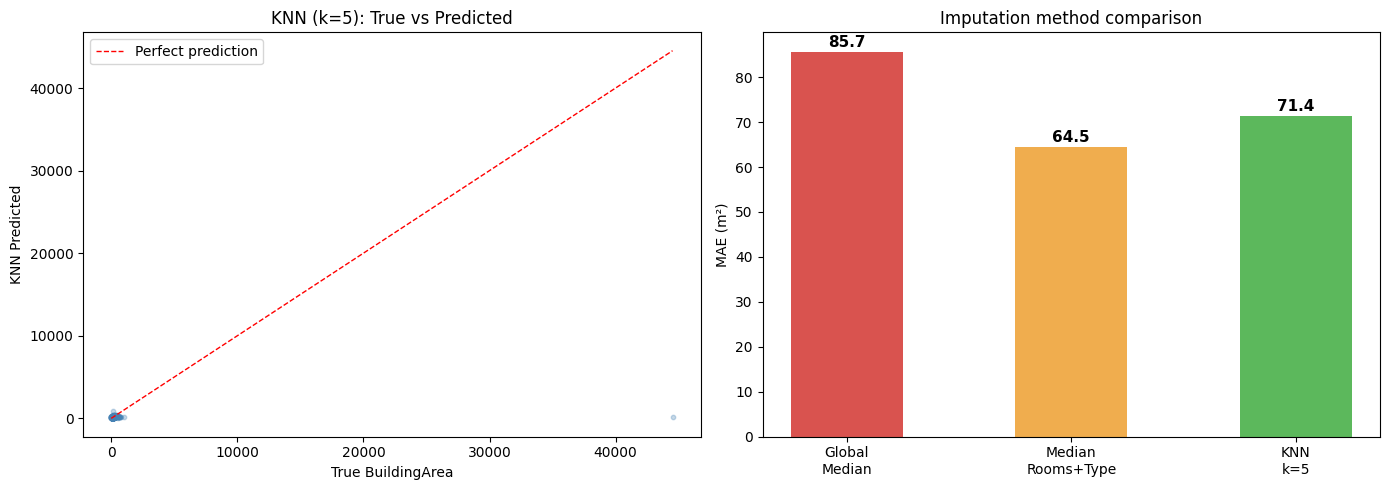


--- Decision helper ---
KNN improves over grouped median by: -10.7%
❌ Recommendation: stick with median by Rooms+Type — KNN is not better


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error

# ============================================================
# KNN IMPUTATION — TEST MODE
# We hide 20% of known values, impute them, and measure error
# This simulates how well KNN would fill real missing values
# ============================================================

# ------------------------------------------------------------
# STEP 1: Prepare test dataset from complete cases only
# We use only rows where BuildingArea is known
# ------------------------------------------------------------
features = ['BuildingArea', 'Rooms', 'Bathroom', 'Car', 'Price']
test = df_complete[features].copy()

# ------------------------------------------------------------
# STEP 2: Artificially hide 20% of BuildingArea values
# These become our "fake missing" to test accuracy
# ------------------------------------------------------------
np.random.seed(42)
mask = np.random.rand(len(test)) < 0.2
true_values = test.loc[mask, 'BuildingArea'].copy()
test.loc[mask, 'BuildingArea'] = np.nan

print(f"Test size     : {len(test)} rows")
print(f"Hidden values : {mask.sum()} rows ({mask.mean()*100:.1f}%)\n")

# ------------------------------------------------------------
# STEP 3: Test different k values and measure MAE
# MAE = average error in m² between real and imputed values
# Lower MAE = better imputation
# ------------------------------------------------------------
results = {}

for k in [3, 5, 10, 15, 20]:
    imputer = KNNImputer(n_neighbors=k)
    imputed = imputer.fit_transform(test)
    predicted = imputed[mask, 0]
    mae = mean_absolute_error(true_values, predicted)
    results[k] = mae
    print(f"k={k:3}  |  MAE = {mae:.1f} m²")

best_k = min(results, key=results.get)
print(f"\n✅ Best k = {best_k}  |  MAE = {results[best_k]:.1f} m²")

# ------------------------------------------------------------
# STEP 4: Compare KNN vs Median imputation on same test data
# Median baseline — impute everything with global median
# ------------------------------------------------------------
global_median = df_complete['BuildingArea'].median()
median_mae = mean_absolute_error(true_values,
                                  [global_median] * mask.sum())

grouped_median = df_complete.groupby(['Rooms', 'Type'])['BuildingArea'].median()

def get_median(row):
    key = (row['Rooms'], row['Type'])
    return grouped_median.get(key, global_median)

median_by_group = df_complete[mask].apply(get_median, axis=1)
group_median_mae = mean_absolute_error(true_values, median_by_group)

print(f"\n--- Comparison ---")
print(f"Global median MAE          : {median_mae:.1f} m²")
print(f"Median by Rooms+Type MAE   : {group_median_mae:.1f} m²")
print(f"KNN (best k={best_k}) MAE  : {results[best_k]:.1f} m²")

winner = "KNN" if results[best_k] < group_median_mae else "Median by group"
print(f"\n🏆 Winner: {winner}")

# ------------------------------------------------------------
# STEP 5: Visual comparison
# Left  — true vs predicted scatter (closer to diagonal = better)
# Right — MAE bar chart for all methods
# ------------------------------------------------------------
imputer_best = KNNImputer(n_neighbors=best_k)
imputed_best = imputer_best.fit_transform(test)
predicted_best = imputed_best[mask, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: true vs predicted
axes[0].scatter(true_values, predicted_best, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, true_values.max()], [0, true_values.max()],
             'r--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('True BuildingArea')
axes[0].set_ylabel('KNN Predicted')
axes[0].set_title(f'KNN (k={best_k}): True vs Predicted')
axes[0].legend()

# MAE comparison bar chart
methods = ['Global\nMedian', 'Median\nRooms+Type', f'KNN\nk={best_k}']
maes    = [median_mae, group_median_mae, results[best_k]]
colors  = ['#d9534f', '#f0ad4e', '#5cb85c']

bars = axes[1].bar(methods, maes, color=colors, width=0.5)
axes[1].set_ylabel('MAE (m²)')
axes[1].set_title('Imputation method comparison')
for bar, val in zip(bars, maes):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# STEP 6: Decision helper
# Based on MAE — suggest whether to apply KNN or not
# ------------------------------------------------------------
improvement = (group_median_mae - results[best_k]) / group_median_mae * 100

print(f"\n--- Decision helper ---")
print(f"KNN improves over grouped median by: {improvement:.1f}%")

if improvement > 10:
    print("✅ Recommendation: apply KNN imputation — meaningful improvement")
elif improvement > 0:
    print("⚠️  Recommendation: marginal improvement — your call")
else:
    print("❌ Recommendation: stick with median by Rooms+Type — KNN is not better")

In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

features_for_model = ['Rooms', 'Bathroom', 'Car', 'Landsize', 'Price', 'Distance']

# Готуємо train/test на повних даних
X = df_complete[features_for_model].fillna(df_complete[features_for_model].median())
y = df_complete['BuildingArea']

np.random.seed(42)
train_mask = np.random.rand(len(X)) > 0.2

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_mae = mean_absolute_error(y_test, rf.predict(X_test))

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_mae = mean_absolute_error(y_test, lr.predict(X_test))

print(f"Random Forest MAE  : {rf_mae:.1f} m²")
print(f"Linear Regression  : {lr_mae:.1f} m²")
print(f"Median Rooms+Type  : 64.5 m²  (baseline)")

Random Forest MAE  : 65.5 m²
Linear Regression  : 61.6 m²
Median Rooms+Type  : 64.5 m²  (baseline)


In [49]:
print(df_complete[df_complete['BuildingArea'] > 1000]['BuildingArea'].count())
print(df_complete[df_complete['BuildingArea'] > 500]['BuildingArea'].count())

# Розподіл без викидів
df_complete([df_complete['BuildingArea'] < 500]|[df_complete['BuildingArea'] > 20])['BuildingArea'].describe()

8
63


TypeError: unsupported operand type(s) for |: 'list' and 'list'

In [50]:
mask_range = (df_complete['BuildingArea'] >= 25) & (df_complete['BuildingArea'] <= 500)

print(f"Total complete rows        : {len(df_complete)}")
print(f"Rows between 25-500 m²     : {mask_range.sum()}")
print(f"Percentage                 : {mask_range.mean()*100:.1f}%")
print(f"Outliers excluded          : {(~mask_range).sum()}\n")

df_complete[mask_range]['BuildingArea'].describe()

Total complete rows        : 7113
Rows between 25-500 m²     : 6968
Percentage                 : 98.0%
Outliers excluded          : 145



,BuildingArea
count,6968.000000
mean,141.568560
std,70.312797
min,25.000000
25%,94.000000
50%,126.000000
75%,173.000000
max,500.000000


Rows for analysis: 6968 (98.0% of complete data)

--- Correlation ---
BuildingArea    1.000000
Rooms           0.726269
Bedroom2        0.712459
Bathroom        0.670182
Price           0.629508
Car             0.398132
Landsize        0.095788
Name: BuildingArea, dtype: float64

--- Single features: spread & CV ---
Type                 | розкид медіан: 69м² | CV: 39.9%
Regionname           | розкид медіан: 41м² | CV: 52.5%
Rooms                | розкид медіан: 266м² | CV: 48.4%

--- Combinations: spread & CV ---
Rooms + Type                   | розкид: 267м² | CV: 36.6%
Rooms + Regionname             | розкид: 361м² | CV: 42.5%
Type + Regionname              | розкид: 99м² | CV: 41.2%
Rooms + Type + Regionname      | розкид: 368м² | CV: 34.7%

--- MAE comparison (no outliers) ---
Median Rooms+Type  : 31.5 m²
KNN k=5            : 34.8 m²
Linear Regression  : 25.9 m²
Random Forest      : 30.3 m²


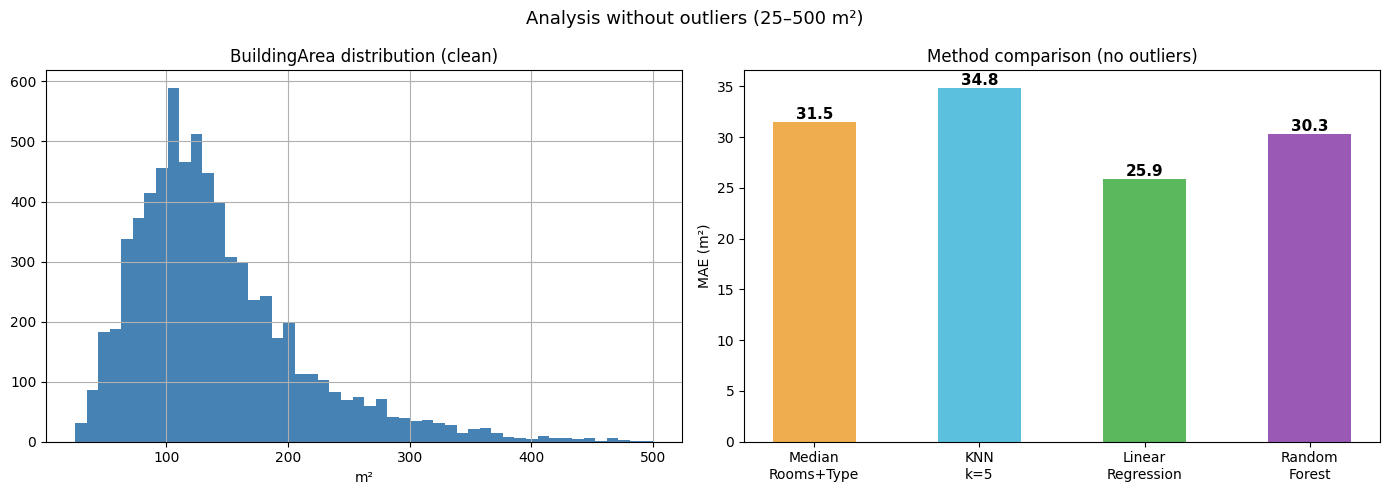

In [51]:
# ============================================================
# RE-RUN ALL DEPENDENCY ANALYSIS — EXCLUDING OUTLIERS
# BuildingArea filtered between 25 and 500 m²
# ============================================================

df_clean = df_complete[
    (df_complete['BuildingArea'] >= 25) &
    (df_complete['BuildingArea'] <= 500)
].copy()

print(f"Rows for analysis: {len(df_clean)} ({len(df_clean)/len(df_complete)*100:.1f}% of complete data)\n")

# ------------------------------------------------------------
# 1. Correlation with numeric features
# ------------------------------------------------------------
corr = df_clean[['BuildingArea','Rooms','Bedroom2','Bathroom','Car','Landsize','Price']]\
    .corr()['BuildingArea'].sort_values(ascending=False)
print("--- Correlation ---")
print(corr)

# ------------------------------------------------------------
# 2. Group consistency — single features
# ------------------------------------------------------------
print("\n--- Single features: spread & CV ---")
for col in ['Type', 'Regionname', 'Rooms']:
    grouped   = df_clean.groupby(col)['BuildingArea'].median()
    spread    = grouped.max() - grouped.min()
    cv        = df_clean.groupby(col)['BuildingArea'].std().mean() / \
                df_clean['BuildingArea'].median() * 100
    print(f"{col:20} | розкид медіан: {spread:.0f}м² | CV: {cv:.1f}%")

# ------------------------------------------------------------
# 3. Group consistency — combinations
# ------------------------------------------------------------
print("\n--- Combinations: spread & CV ---")
combos = {
    'Rooms + Type'             : ['Rooms', 'Type'],
    'Rooms + Regionname'       : ['Rooms', 'Regionname'],
    'Type + Regionname'        : ['Type', 'Regionname'],
    'Rooms + Type + Regionname': ['Rooms', 'Type', 'Regionname'],
}

for name, cols in combos.items():
    grouped = df_clean.groupby(cols)['BuildingArea']
    cv      = grouped.std().mean() / df_clean['BuildingArea'].median() * 100
    spread  = grouped.median().max() - grouped.median().min()
    print(f"{name:30} | розкид: {spread:.0f}м² | CV: {cv:.1f}%")

# ------------------------------------------------------------
# 4. Re-run MAE comparison on clean data
# ------------------------------------------------------------
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

features = ['BuildingArea', 'Rooms', 'Bathroom', 'Car', 'Price']
test = df_clean[features].copy()

np.random.seed(42)
mask = np.random.rand(len(test)) < 0.2
true_values = test.loc[mask, 'BuildingArea'].copy()
test.loc[mask, 'BuildingArea'] = np.nan

# Median by Rooms+Type
grouped_median = df_clean.groupby(['Rooms','Type'])['BuildingArea'].median()
global_median  = df_clean['BuildingArea'].median()
median_pred    = df_clean[mask].apply(
    lambda row: grouped_median.get((row['Rooms'], row['Type']), global_median), axis=1)
median_mae = mean_absolute_error(true_values, median_pred)

# KNN
knn = KNNImputer(n_neighbors=5)
knn_imputed = knn.fit_transform(test)
knn_mae = mean_absolute_error(true_values, knn_imputed[mask, 0])

# Linear Regression
X = df_clean[['Rooms','Bathroom','Car','Price']].fillna(df_clean[['Rooms','Bathroom','Car','Price']].median())
y = df_clean['BuildingArea']
train_mask = np.random.rand(len(X)) > 0.2
lr = LinearRegression()
lr.fit(X[train_mask], y[train_mask])
lr_mae = mean_absolute_error(y[~train_mask], lr.predict(X[~train_mask]))

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X[train_mask], y[train_mask])
rf_mae = mean_absolute_error(y[~train_mask], rf.predict(X[~train_mask]))

print(f"\n--- MAE comparison (no outliers) ---")
print(f"Median Rooms+Type  : {median_mae:.1f} m²")
print(f"KNN k=5            : {knn_mae:.1f} m²")
print(f"Linear Regression  : {lr_mae:.1f} m²")
print(f"Random Forest      : {rf_mae:.1f} m²")

# ------------------------------------------------------------
# 5. Visual summary
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analysis without outliers (25–500 m²)', fontsize=13)

df_clean['BuildingArea'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('BuildingArea distribution (clean)')
axes[0].set_xlabel('m²')

methods = ['Median\nRooms+Type', 'KNN\nk=5', 'Linear\nRegression', 'Random\nForest']
maes    = [median_mae, knn_mae, lr_mae, rf_mae]
colors  = ['#f0ad4e', '#5bc0de', '#5cb85c', '#9b59b6']
bars    = axes[1].bar(methods, maes, color=colors, width=0.5)
axes[1].set_ylabel('MAE (m²)')
axes[1].set_title('Method comparison (no outliers)')
for bar, val in zip(bars, maes):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Model coefficients:
  Rooms        : 27.9671
  Bathroom     : 27.1557
  Car          : 5.7543
  Price        : 0.0000
  Intercept    : -25.9184

Missing before : 6467
Missing after  : 0

--- Statistics comparison ---
       Before (known)  After (imputed)
count         7113.00         13580.00
mean           152.33           144.48
std            541.61           393.76
min              1.00             1.00
25%             93.00            94.00
50%            126.00           127.00
75%            174.00           169.99
max          44515.00         44515.00

Mean shift   : 5.2%
Median shift : 0.8%
Std shift    : 27.3%

⚠️  Minor shift — acceptable but worth noting


/tmp/ipykernel_12113/2032003476.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


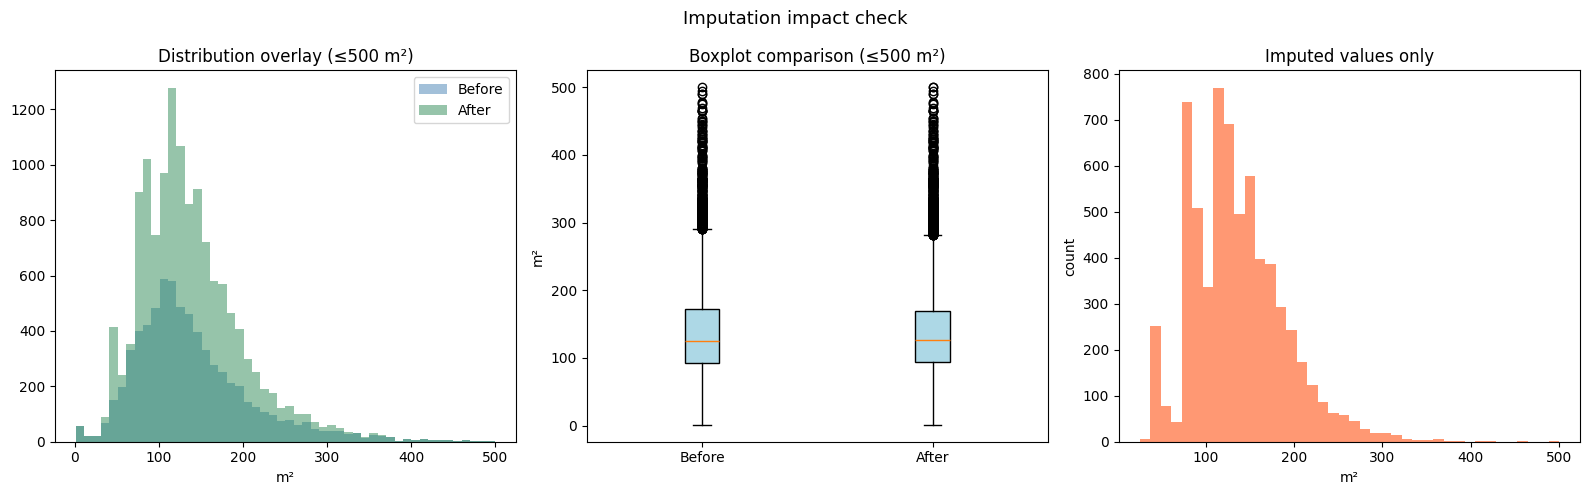


--- Sanity check: mean BuildingArea by Type ---
      Known  Imputed  Difference  Diff %
Type                                    
h     177.4    150.9       -26.5   -14.9
t     140.7    140.8         0.1     0.1
u      80.7     85.8         5.1     6.3


In [52]:
# ============================================================
# LINEAR REGRESSION IMPUTATION — TEST MODE
# Apply on a copy, compare statistics before and after
# ============================================================

from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# STEP 1: Work on a copy — original df stays untouched
# ------------------------------------------------------------
df_test = df.copy()

# ------------------------------------------------------------
# STEP 2: Train model on clean data (25-500 m², no outliers)
# ------------------------------------------------------------
features_model = ['Rooms', 'Bathroom', 'Car', 'Price']

X_train = df_clean[features_model].fillna(df_clean[features_model].median())
y_train = df_clean['BuildingArea']

lr_final = LinearRegression()
lr_final.fit(X_train, y_train)

print("Model coefficients:")
for feat, coef in zip(features_model, lr_final.coef_):
    print(f"  {feat:12} : {coef:.4f}")
print(f"  Intercept    : {lr_final.intercept_:.4f}")

# ------------------------------------------------------------
# STEP 3: Predict and fill missing values
# Clip predictions to realistic range 25-500 m²
# ------------------------------------------------------------
missing_mask = df_test['BuildingArea'].isna()
print(f"\nMissing before : {missing_mask.sum()}")

X_missing  = df_test[missing_mask][features_model]\
    .fillna(df[features_model].median())
predicted  = lr_final.predict(X_missing)
predicted  = np.clip(predicted, 25, 500)

df_test.loc[missing_mask, 'BuildingArea'] = predicted

print(f"Missing after  : {df_test['BuildingArea'].isna().sum()}")

# ------------------------------------------------------------
# STEP 4: Compare statistics before and after
# Key check — did mean/median/std shift dramatically?
# ------------------------------------------------------------
before = df_complete['BuildingArea']          # original known values
after  = df_test['BuildingArea']              # after imputation

stats = pd.DataFrame({
    'Before (known)': before.describe(),
    'After (imputed)': after.describe()
})
print(f"\n--- Statistics comparison ---")
print(stats.round(2))

shift_mean   = abs(after.mean()   - before.mean())   / before.mean()   * 100
shift_median = abs(after.median() - before.median()) / before.median() * 100
shift_std    = abs(after.std()    - before.std())    / before.std()    * 100

print(f"\nMean shift   : {shift_mean:.1f}%")
print(f"Median shift : {shift_median:.1f}%")
print(f"Std shift    : {shift_std:.1f}%")

if max(shift_mean, shift_median) < 5:
    print("\n✅ Distribution preserved — safe to apply")
elif max(shift_mean, shift_median) < 10:
    print("\n⚠️  Minor shift — acceptable but worth noting")
else:
    print("\n❌ Significant distortion — reconsider imputation strategy")

# ------------------------------------------------------------
# STEP 5: Visual check
# Compare distributions before and after
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Imputation impact check', fontsize=13)

# Distribution overlay
axes[0].hist(before[before <= 500], bins=50,
             alpha=0.5, color='steelblue', label='Before')
axes[0].hist(after[after <= 500],   bins=50,
             alpha=0.5, color='seagreen',  label='After')
axes[0].set_title('Distribution overlay (≤500 m²)')
axes[0].set_xlabel('m²')
axes[0].legend()

# Boxplot comparison
axes[1].boxplot(
    [before[before <= 500], after[after <= 500]],
    labels=['Before', 'After'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)
axes[1].set_title('Boxplot comparison (≤500 m²)')
axes[1].set_ylabel('m²')

# Imputed values distribution
axes[2].hist(predicted, bins=40, color='coral', alpha=0.8)
axes[2].set_title('Imputed values only')
axes[2].set_xlabel('m²')
axes[2].set_ylabel('count')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# STEP 6: Check imputed values make sense by Type
# Imputed averages should be close to known averages
# ------------------------------------------------------------
print("\n--- Sanity check: mean BuildingArea by Type ---")
comparison = pd.DataFrame({
    'Known'  : df_complete.groupby('Type')['BuildingArea'].mean(),
    'Imputed': df_test[missing_mask].groupby(
                   df_test[missing_mask]['Type'])['BuildingArea'].mean()
}).round(1)
comparison['Difference'] = (comparison['Imputed'] - comparison['Known']).round(1)
comparison['Diff %']     = ((comparison['Difference'] / comparison['Known']) * 100).round(1)
print(comparison)

In [ ]:
df['BuildingArea'] = df_test['BuildingArea']
print("Imputation applied successfully!")
print(f"Missing values remaining: {df['BuildingArea'].isna().sum()}")

https://raw.githubusercontent.com/T-Svitlichna/Melbourne_housing/refs/heads/main/data/melb_data.csv